# Notebook 09 — Sensitivity Analysis
Compute station-level weather sensitivity/resilience scores,
rank stations, and produce policy-ready outputs.

## 0. Imports & Load

In [1]:
from pathlib import Path

import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Patch

%matplotlib inline
plt.rcParams["figure.dpi"] = 120

ROOT      = Path().resolve().parent
PROCESSED = ROOT / "data" / "processed"
FIGS      = ROOT / "outputs" / "figures"
FIGS.mkdir(parents=True, exist_ok=True)

COLORS = {
    "commuter" : "#2196F3",
    "mixed"    : "#FFC107",
    "leisure"  : "#F44336",
}

panel      = pd.read_parquet(PROCESSED / "analysis_panel.parquet")
site_stats = pd.read_parquet(PROCESSED / "site_classification.parquet")

panel_good = panel[panel["low_coverage"] == False].copy()
panel_good["date"] = pd.to_datetime(panel_good["date"])

print(f"panel_good  : {panel_good.shape}")
print(f"site_stats  : {site_stats.shape}")
print(f"date range  : {panel_good['date'].min().date()} → {panel_good['date'].max().date()}")

panel_good  : (145768, 54)
site_stats  : (133, 14)
date range  : 2023-01-01 → 2025-12-31


## 1. Station-Level Resilience Scores
**Method:** for each station, `resilience = bad_weather_avg / good_weather_avg`  
Score ≈ 1.0 → weather has little effect (resilient)  
Score ≪ 1.0 → demand collapses in bad weather (sensitive)

In [2]:
def compute_resilience(df, weather_col, label):
    good = df[df[weather_col] == False].groupby("site ID")["aantal"].mean()
    bad  = df[df[weather_col] == True].groupby("site ID")["aantal"].mean()
    return (bad / good).rename(label)

r_rain = compute_resilience(panel_good, "is_rainy_day",  "resilience_rain") # rainy_day is True if precipitation > 0.1mm
r_cold = compute_resilience(panel_good, "is_cold_day",   "resilience_cold") # cold_day is True if min temp < 5°C
r_wind = compute_resilience(panel_good, "is_windy_day",  "resilience_wind") # windy_day is True if max wind speed > 30 km/h
r_any  = compute_resilience(panel_good, "is_bad_weather", "resilience_any") # is_bad_weather is True if any of the 3 conditions is met, so it captures the combined effect

resilience = (
    pd.DataFrame({"site ID": panel_good["site ID"].unique()})
    .set_index("site ID")
    .join([r_rain, r_cold, r_wind, r_any])
    .reset_index()
)

resilience["resilience_score"] = (
    resilience["resilience_rain"] * 0.45 +
    resilience["resilience_cold"] * 0.25 +
    resilience["resilience_wind"] * 0.20 +
    resilience["resilience_any"]  * 0.10
)

resilience = resilience.merge(
    site_stats[["site ID", "naam", "gemeente", "avg_daily",
                "site_type", "lon", "lat"]],
    on="site ID", how="left"
)

resilience["sensitivity_rank"] = resilience["resilience_score"].rank(
    ascending=True
).astype(int)
resilience = resilience.sort_values("sensitivity_rank")

print("Resilience score distribution:")
print(resilience["resilience_score"].describe().round(3))
print()
print("Top 15 most sensitive stations (lowest resilience):")
print(resilience.head(15)[["naam", "gemeente", "site_type",
                            "resilience_score", "avg_daily"]].to_string(index=False))
print()
print("Top 15 most resilient stations (highest resilience):")
print(resilience.nlargest(15, "resilience_score")[
    ["naam", "gemeente", "site_type", "resilience_score", "avg_daily"]
].to_string(index=False))
print()
lt_rank = resilience.loc[resilience["site ID"] == 107, "sensitivity_rank"].values
lt_score = resilience.loc[resilience["site ID"] == 107, "resilience_score"].values
print(f"Leuven Totem (site ID 107): sensitivity rank #{lt_rank[0]}, "
      f"resilience score {lt_score[0]:.3f}")

Resilience score distribution:
count    133.000
mean       0.631
std        0.096
min        0.330
25%        0.586
50%        0.631
75%        0.689
max        0.846
Name: resilience_score, dtype: float64

Top 15 most sensitive stations (lowest resilience):
                      naam             gemeente site_type  resilience_score   avg_daily
                        As                   As   leisure          0.329600  669.448792
      Houthalen-Helchteren Houthalen-Helchteren   leisure          0.391295  445.731506
          Nieuwpoort totem           Nieuwpoort   leisure          0.397025 1050.261841
       Nieuwpoort teller 1           Nieuwpoort   leisure          0.401325 2145.483643
            Heers teller 1                Heers   leisure          0.412358   69.660019
                     Heers                Heers   leisure          0.413620   63.970802
          Maaseik teller 2              Maaseik   leisure          0.444064  449.500000
          Maaseik teller 1           

## 2. Sensitivity by Site Type

In [3]:
by_type = resilience.groupby("site_type")[
    ["resilience_rain", "resilience_cold",
     "resilience_wind", "resilience_score"]
].mean().round(3)
print("Average resilience by site type:")
print(by_type)

Average resilience by site type:
           resilience_rain  resilience_cold  resilience_wind  resilience_score
site_type                                                                     
commuter             0.731            0.726            0.458             0.669
leisure              0.668            0.571            0.373             0.576
mixed                0.690            0.647            0.405             0.616


## 3. Commuting-Period Weather Sensitivity

In [4]:
def commute_effects(df):
    morning = df[df["precip_morning"] > 0.5]["aantal"].mean() / \
              df[df["precip_morning"] <= 0.5]["aantal"].mean() - 1
    evening = df[df["precip_evening"] > 0.5]["aantal"].mean() / \
              df[df["precip_evening"] <= 0.5]["aantal"].mean() - 1
    return pd.Series({"morning_rain_effect": morning,
                      "evening_rain_effect": evening})

commute_sensitivity = (
    panel_good.groupby("site ID")
    .apply(commute_effects, include_groups=False)
    .reset_index()
    .merge(site_stats[["site ID", "naam", "site_type"]], on="site ID")
)

ct = commute_sensitivity.groupby("site_type")[
    ["morning_rain_effect", "evening_rain_effect"]
].mean().round(3)
print("Commute-period rain effect by site type:")
print(ct)

c_morn = ct.loc["commuter", "morning_rain_effect"]
l_morn = ct.loc["leisure",  "morning_rain_effect"]
rel    = (c_morn - l_morn) / abs(l_morn) * 100
print(f"\nCommuters are {abs(rel):.1f}% less affected than leisure "
      f"by morning rain")

Commute-period rain effect by site type:
           morning_rain_effect  evening_rain_effect
site_type                                          
commuter                -0.356               -0.256
leisure                 -0.436               -0.332
mixed                   -0.410               -0.295

Commuters are 18.3% less affected than leisure by morning rain


## 4. Priority Infrastructure List

In [5]:
resilience["priority_score"] = (
    (1 - resilience["resilience_score"]) *
    np.log1p(resilience["avg_daily"])
)
resilience["priority_rank"] = resilience["priority_score"].rank(
    ascending=False
).astype(int)

priority_list = resilience.sort_values("priority_rank").head(20)[
    ["priority_rank", "naam", "gemeente", "site_type",
     "avg_daily", "resilience_score", "resilience_rain",
     "resilience_cold", "resilience_wind", "priority_score"]
]
print("Top 20 Priority Stations for Infrastructure Investment:")
print(priority_list.to_string(index=False))

Top 20 Priority Stations for Infrastructure Investment:
 priority_rank                 naam             gemeente site_type   avg_daily  resilience_score  resilience_rain  resilience_cold  resilience_wind  priority_score
             1  Nieuwpoort teller 1           Nieuwpoort   leisure 2145.483643          0.401325         0.544893         0.271693         0.228666        4.592790
             2                   As                   As   leisure  669.448792          0.329600         0.467122         0.254500         0.103098        4.362930
             3     Nieuwpoort totem           Nieuwpoort   leisure 1050.261841          0.397025         0.544032         0.262462         0.221914        4.195349
             4 Houthalen-Helchteren Houthalen-Helchteren   leisure  445.731506          0.391295         0.549689         0.315039         0.105062        3.714290
             5     Maaseik teller 2              Maaseik   leisure  449.500000          0.444064         0.558699         0.

## 5. Visualisations

### Resilience Score Distribution

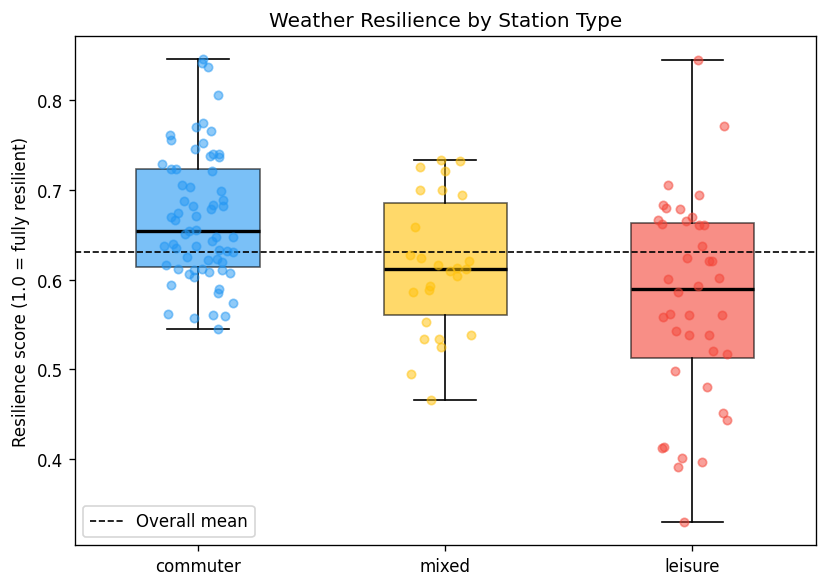

09_resilience_distribution.png saved.


In [6]:
fig, ax = plt.subplots(figsize=(7, 5))

order       = ["commuter", "mixed", "leisure"]
data        = [resilience[resilience["site_type"] == st]["resilience_score"].values
               for st in order]
colors_list = [COLORS[st] for st in order]

bp = ax.boxplot(data, patch_artist=True, widths=0.5,
                medianprops=dict(color="black", linewidth=2))
for patch, color in zip(bp["boxes"], colors_list):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

rng = np.random.default_rng(42)
for i, (d, color) in enumerate(zip(data, colors_list), start=1):
    jitter = rng.uniform(-0.15, 0.15, size=len(d))
    ax.scatter(i + jitter, d, color=color, alpha=0.5, s=25, zorder=3)

ax.axhline(resilience["resilience_score"].mean(),
           color="black", linestyle="--", linewidth=1, label="Overall mean")
ax.set_xticks([1, 2, 3])
ax.set_xticklabels(order)
ax.set_ylabel("Resilience score (1.0 = fully resilient)")
ax.set_title("Weather Resilience by Station Type")
ax.legend()

fig.tight_layout()
fig.savefig(FIGS / "09_resilience_distribution.png", dpi=150)
plt.show()
print("09_resilience_distribution.png saved.")

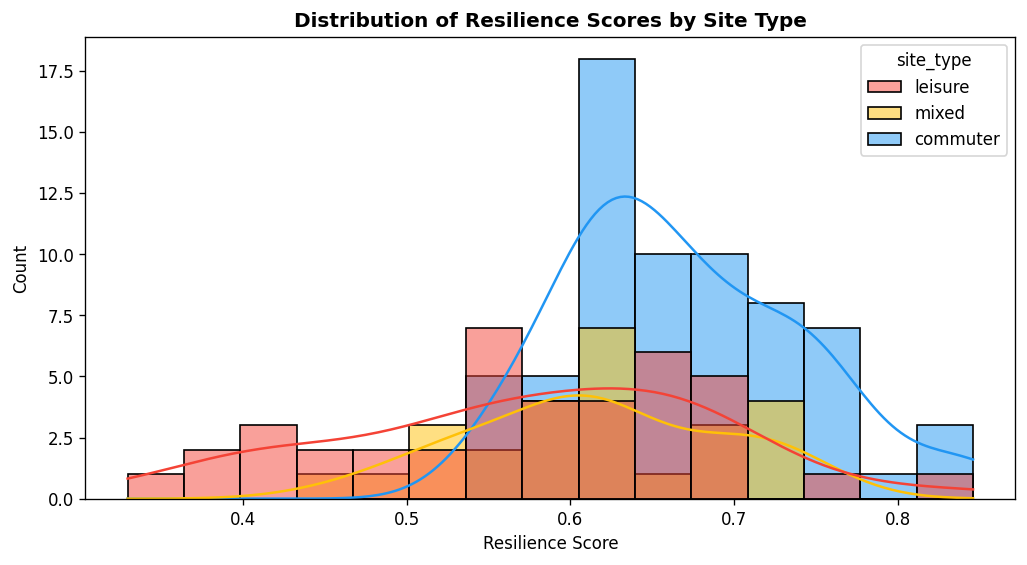

In [4]:
import seaborn as sns
plt.figure(figsize=(10, 5), dpi=120)
sns.histplot(data=resilience, x="resilience_score", hue="site_type", 
             kde=True, palette=COLORS, alpha=0.5, bins=15)
plt.title("Distribution of Resilience Scores by Site Type", fontweight="bold")
plt.xlabel("Resilience Score")
plt.ylabel("Count")
plt.show()

In [15]:
# check normality and variance homogeneity for ANOVA assumptions
import scipy.stats as stats
print("="*60)
print("1. NORMALITY TEST (Shapiro-Wilk)")
print("   (H0: The data is normally distributed; p > 0.05 is good)")
print("="*60)
stat, p_norm = stats.shapiro(resilience["resilience_score"])
print(f"Overall Score Normal: p-value = {p_norm:.4f} \n (Note: This tests the entire dataset, but we also need to check each site type separately)")

groups = [resilience[resilience["site_type"] == st]["resilience_score"].values for st in ["commuter", "leisure", "mixed"]]
for st, grp in zip(["commuter", "leisure", "mixed"], groups):
    _, p = stats.shapiro(grp)
    print(f"  - {st:<10}: p-value = {p:.4f}")

print("\n" + "="*60)
print("2. VARIANCE HOMOGENEITY TEST (Levene's Test)")
print("   (H0: All groups have equal variances; p > 0.05 is good)")
print("="*60)
stat, p_levene = stats.levene(*groups)
print(f"Equal Variance: p-value = {p_levene:.4f}")

1. NORMALITY TEST (Shapiro-Wilk)
   (H0: The data is normally distributed; p > 0.05 is good)
Overall Score Normal: p-value = 0.0410 
 (Note: This tests the entire dataset, but we also need to check each site type separately)
  - commuter  : p-value = 0.0438
  - leisure   : p-value = 0.4801
  - mixed     : p-value = 0.2545

2. VARIANCE HOMOGENEITY TEST (Levene's Test)
   (H0: All groups have equal variances; p > 0.05 is good)
Equal Variance: p-value = 0.0065


In [18]:
# we have non-nomality and heteroscedasticity, so we go with non-parametric Kruskal-Wallis test
stat_kw, p_kw = stats.kruskal(*groups)
print(f"Kruskal-Wallis test p-value : {p_kw:.5f}")

if p_kw < 0.05:
    print("\nResult: SIGNIFICANT DIFFERENCE DETECTED! Performing pairwise checks (Mann-Whitney U):")
    pairs = [("commuter", "leisure"), ("commuter", "mixed"), ("leisure", "mixed")]
    for st1, st2 in pairs:
        g1 = resilience[resilience["site_type"] == st1]["resilience_score"]
        g2 = resilience[resilience["site_type"] == st2]["resilience_score"]
        _, p_pair = stats.mannwhitneyu(g1, g2, alternative='two-sided')
        
        #  Bonferroni correction for multiple comparisons (3 pairs)
        p_adj = min(p_pair * 3, 1.0) 
        sig = "***" if p_adj < 0.01 else ("*" if p_adj < 0.05 else "not significant")
        print(f"  {st1:<10} vs {st2:<10} | adjusted p-val = {p_adj:.4f} {sig}")

Kruskal-Wallis test p-value : 0.00003

Result: SIGNIFICANT DIFFERENCE DETECTED! Performing pairwise checks (Mann-Whitney U):
  commuter   vs leisure    | adjusted p-val = 0.0001 ***
  commuter   vs mixed      | adjusted p-val = 0.0122 *
  leisure    vs mixed      | adjusted p-val = 0.5616 not significant


### Priority Map

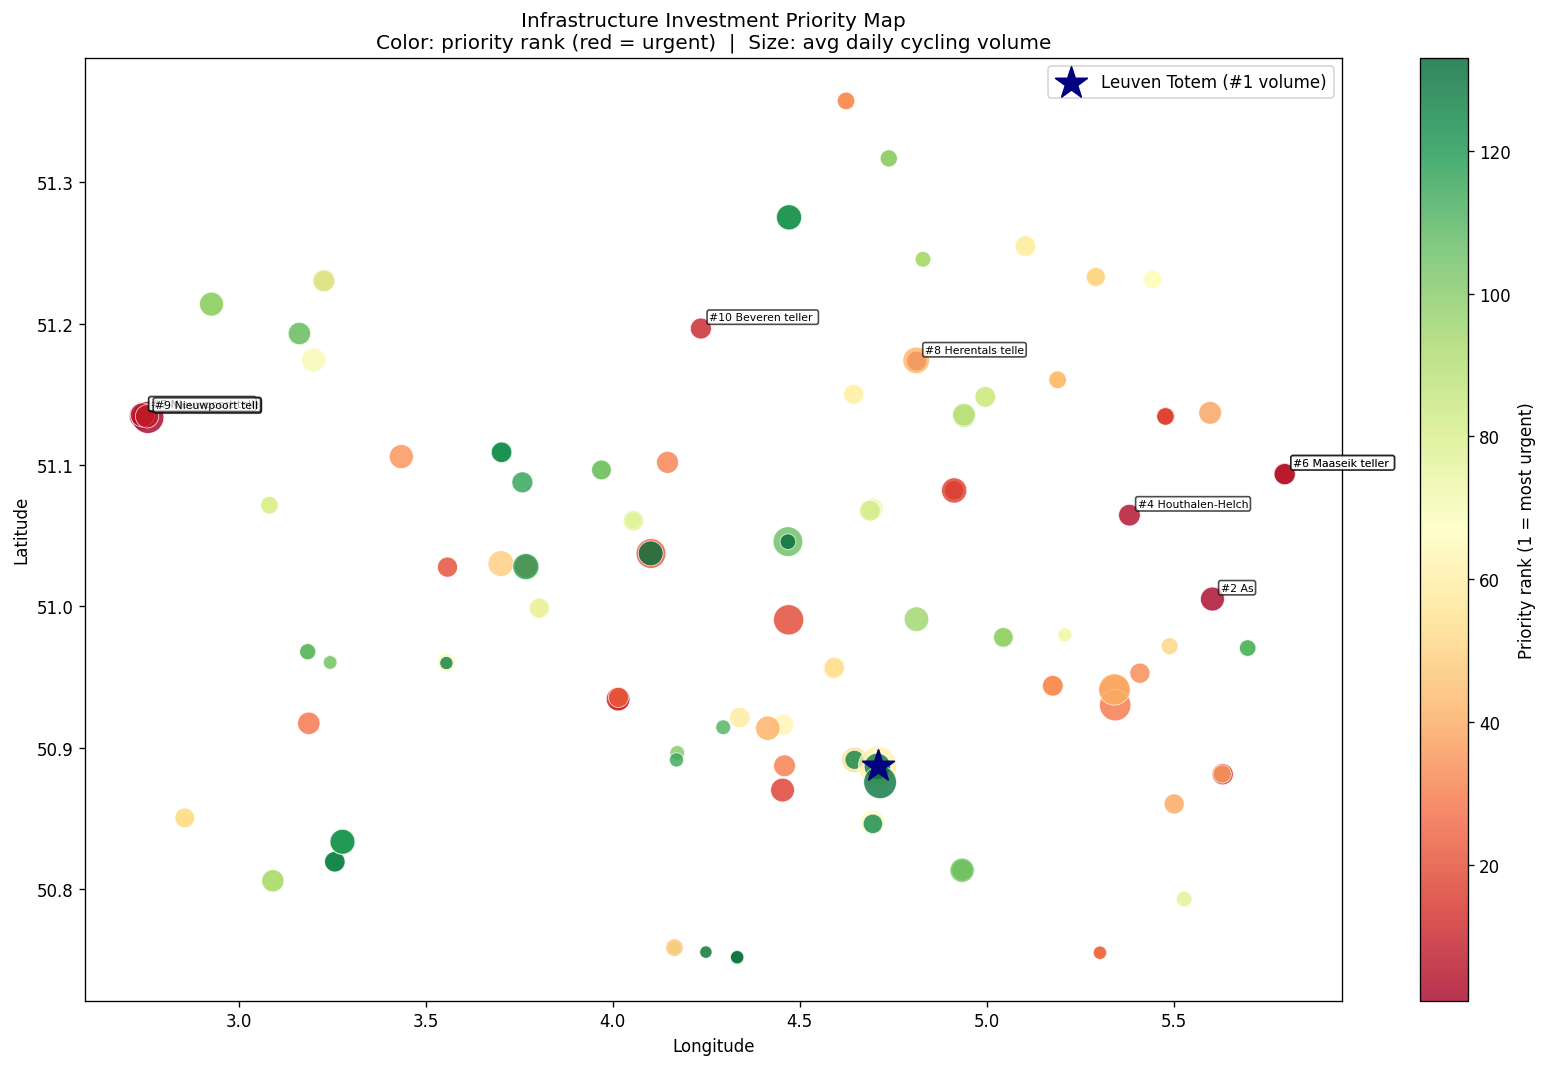

09_priority_map saved.


In [7]:
fig, ax = plt.subplots(figsize=(14, 9))

cmap       = plt.cm.RdYlGn
norm_color = mcolors.Normalize(
    vmin=resilience["priority_rank"].min(),
    vmax=resilience["priority_rank"].max(),
)

scatter = ax.scatter(
    resilience["lon"],
    resilience["lat"],
    c=resilience["priority_rank"],
    cmap=cmap,
    norm=norm_color,
    s=np.sqrt(resilience["avg_daily"]) * 8,
    alpha=0.8,
    edgecolors="white",
    linewidths=0.5,
)

top10 = resilience.sort_values("priority_rank").head(10)
for _, row in top10.iterrows():
    ax.annotate(
        f"#{int(row['priority_rank'])} {row['naam'][:15]}",
        (row["lon"], row["lat"]),
        fontsize=6.5,
        xytext=(5, 5),
        textcoords="offset points",
        bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.7),
    )

lt = resilience[resilience["site ID"] == 107]
ax.scatter(lt["lon"], lt["lat"], color="navy", marker="*",
           s=400, zorder=10, label="Leuven Totem (#1 volume)")

plt.colorbar(scatter, ax=ax, label="Priority rank (1 = most urgent)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title(
    "Infrastructure Investment Priority Map\n"
    "Color: priority rank (red = urgent)  |  Size: avg daily cycling volume",
    fontsize=12,
)
ax.legend()
fig.tight_layout()
fig.savefig(FIGS / "09_priority_map.png", dpi=150)
plt.show()
print("09_priority_map saved.")

### Top 15 Sensitive vs Top 15 Resilient

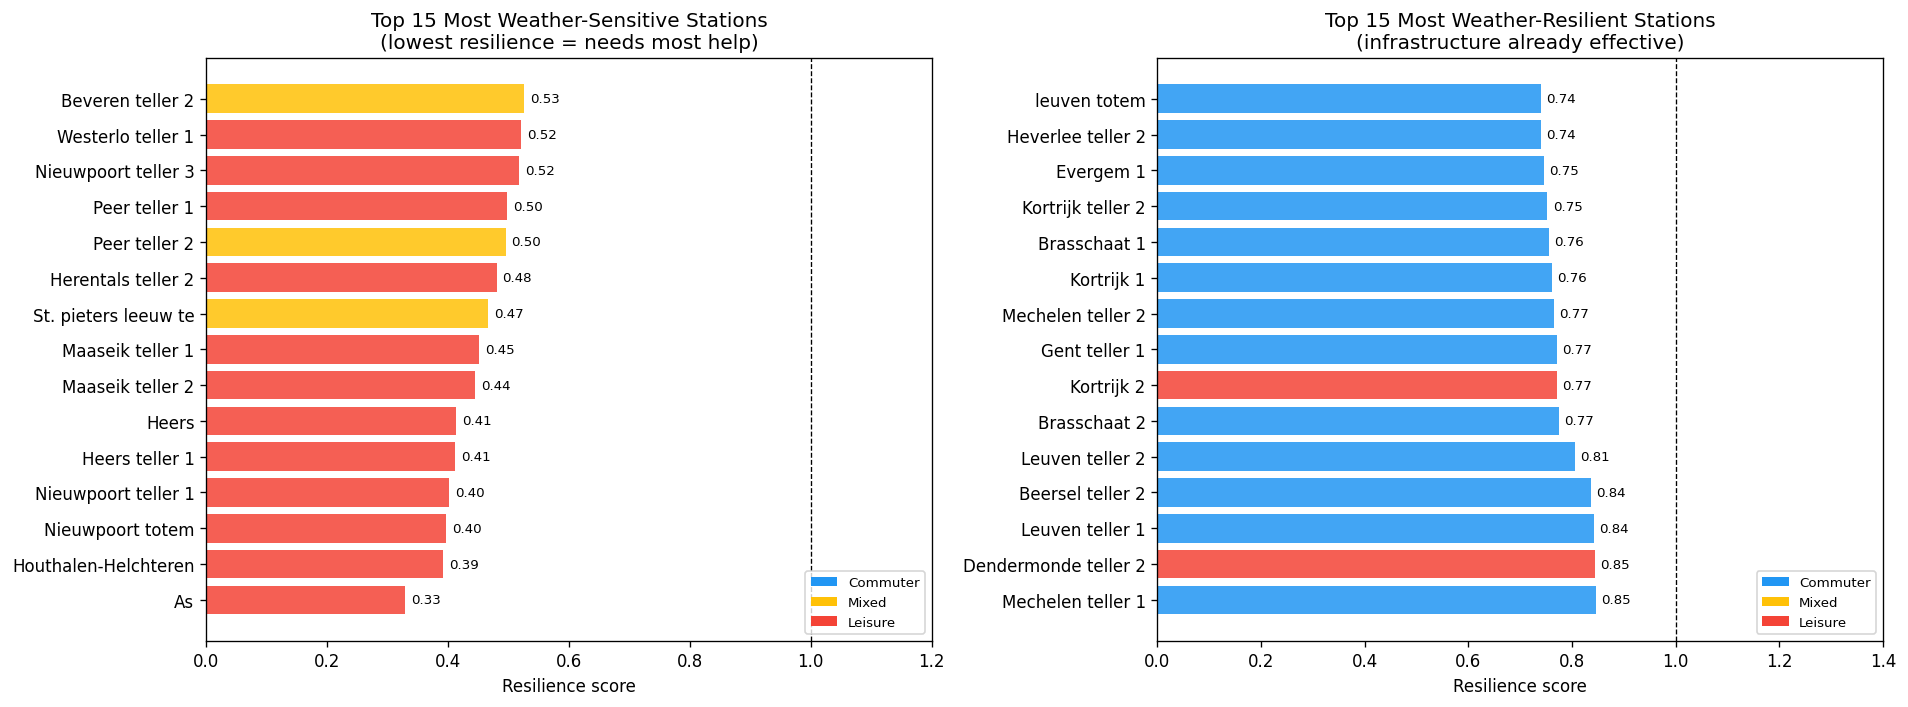

09_sensitive_vs_resilient saved.


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

legend_elements = [
    Patch(facecolor=COLORS["commuter"], label="Commuter"),
    Patch(facecolor=COLORS["mixed"],    label="Mixed"),
    Patch(facecolor=COLORS["leisure"],  label="Leisure"),
]

# Left: top 15 most sensitive
ax = axes[0]
sensitive_15 = resilience.head(15).sort_values("resilience_score", ascending=True)
colors_s = [COLORS.get(st, "gray") for st in sensitive_15["site_type"]]
bars = ax.barh(sensitive_15["naam"].str[:20],
               sensitive_15["resilience_score"],
               color=colors_s, alpha=0.85)
ax.axvline(1.0, color="black", linestyle="--", linewidth=0.8)
ax.set_xlabel("Resilience score")
ax.set_title("Top 15 Most Weather-Sensitive Stations\n"
             "(lowest resilience = needs most help)")
ax.set_xlim(0, 1.2)
for bar, val in zip(bars, sensitive_15["resilience_score"]):
    ax.text(val + 0.01, bar.get_y() + bar.get_height() / 2,
            f"{val:.2f}", va="center", fontsize=8)
ax.legend(handles=legend_elements, loc="lower right", fontsize=8)

# Right: top 15 most resilient
ax = axes[1]
resilient_15 = resilience.nlargest(15, "resilience_score").sort_values(
    "resilience_score", ascending=False)
colors_r = [COLORS.get(st, "gray") for st in resilient_15["site_type"]]
bars = ax.barh(resilient_15["naam"].str[:20],
               resilient_15["resilience_score"],
               color=colors_r, alpha=0.85)
ax.axvline(1.0, color="black", linestyle="--", linewidth=0.8)
ax.set_xlabel("Resilience score")
ax.set_title("Top 15 Most Weather-Resilient Stations\n"
             "(infrastructure already effective)")
ax.set_xlim(0, 1.4)
for bar, val in zip(bars, resilient_15["resilience_score"]):
    ax.text(val + 0.01, bar.get_y() + bar.get_height() / 2,
            f"{val:.2f}", va="center", fontsize=8)
ax.legend(handles=legend_elements, loc="lower right", fontsize=8)

fig.tight_layout()
fig.savefig(FIGS / "09_sensitive_vs_resilient.png", dpi=150)
plt.show()
print("09_sensitive_vs_resilient saved.")

## 6. Save Resilience Results

In [9]:
resilience.to_parquet(PROCESSED / "station_resilience.parquet", index=False)
print(f"Saved: {PROCESSED / 'station_resilience.parquet'}")

Saved: /Users/zhuyuxuan/Downloads/Modern Data Analytics/mda-cycling-weather-group6/data/processed/station_resilience.parquet


## 7. Final Summary

In [10]:
n_stations = resilience["site ID"].nunique()
r_mean     = resilience["resilience_score"].mean()
r_median   = resilience["resilience_score"].median()
r_min      = resilience["resilience_score"].min()
r_max      = resilience["resilience_score"].max()
most_sens  = resilience.loc[resilience["resilience_score"].idxmin(), "naam"]
most_resil = resilience.loc[resilience["resilience_score"].idxmax(), "naam"]

by_type_s  = resilience.groupby("site_type")["resilience_score"].mean()

c_morn_pct = ct.loc["commuter", "morning_rain_effect"] * 100
l_morn_pct = ct.loc["leisure",  "morning_rain_effect"] * 100
rel_diff   = (c_morn_pct - l_morn_pct) / abs(l_morn_pct) * 100

top5 = resilience.sort_values("priority_rank").head(5)

lt_row   = resilience[resilience["site ID"] == 107].iloc[0]

print("=" * 52)
print("SENSITIVITY ANALYSIS SUMMARY")
print("=" * 52)
print(f"Stations analysed: {n_stations} (well-covered)")
print()
print("Overall resilience score distribution:")
print(f"  Mean   : {r_mean:.3f}")
print(f"  Median : {r_median:.3f}")
print(f"  Min    : {r_min:.3f}  (most sensitive: {most_sens})")
print(f"  Max    : {r_max:.3f}  (most resilient: {most_resil})")
print()
print("Resilience by site type:")
for st in ["commuter", "mixed", "leisure"]:
    tag = " (most resilient)" if st == "commuter" else \
          " (most sensitive)" if st == "leisure" else ""
    print(f"  {st:10s}: {by_type_s[st]:.3f}{tag}")
print()
print("Commute-period rain effect:")
print(f"  commuter morning rain : {c_morn_pct:+.1f}%")
print(f"  leisure  morning rain : {l_morn_pct:+.1f}%")
print(f"  \u2192 commuters {abs(rel_diff):.1f}% less affected during morning commute")
print()
print("Top 5 Priority Stations for Investment:")
for _, row in top5.iterrows():
    print(f"  #{int(row['priority_rank'])}  {row['naam'][:25]:<25} "
          f"({row['gemeente']}) — "
          f"resilience: {row['resilience_score']:.3f}, "
          f"avg: {row['avg_daily']:.0f}/day")
print()
print("Leuven Totem (site ID 107):")
print(f"  Resilience score : {lt_row['resilience_score']:.3f}")
print(f"  Sensitivity rank : #{int(lt_row['sensitivity_rank'])} / {n_stations}")
print(f"  Priority rank    : #{int(lt_row['priority_rank'])} / {n_stations}")
print(f"  Rain resilience  : {lt_row['resilience_rain']:.3f}")
print(f"  Cold resilience  : {lt_row['resilience_cold']:.3f}")


SENSITIVITY ANALYSIS SUMMARY
Stations analysed: 133 (well-covered)

Overall resilience score distribution:
  Mean   : 0.631
  Median : 0.631
  Min    : 0.330  (most sensitive: As)
  Max    : 0.846  (most resilient: Mechelen teller 1)

Resilience by site type:
  commuter  : 0.669 (most resilient)
  mixed     : 0.616
  leisure   : 0.576 (most sensitive)

Commute-period rain effect:
  commuter morning rain : -35.6%
  leisure  morning rain : -43.6%
  → commuters 18.3% less affected during morning commute

Top 5 Priority Stations for Investment:
  #1  Nieuwpoort teller 1       (Nieuwpoort) — resilience: 0.401, avg: 2145/day
  #2  As                        (As) — resilience: 0.330, avg: 669/day
  #3  Nieuwpoort totem          (Nieuwpoort) — resilience: 0.397, avg: 1050/day
  #4  Houthalen-Helchteren      (Houthalen-Helchteren) — resilience: 0.391, avg: 446/day
  #5  Maaseik teller 2          (Maaseik) — resilience: 0.444, avg: 450/day

Leuven Totem (site ID 107):
  Resilience score : 0.740
 